<a href="https://colab.research.google.com/github/ahmadoarnaout-netizen/MARKETING-CAMPAIGN-IMPACT-ANALYSIS-/blob/main/MARKETING_CAMPAIGN_IMPACT_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Load Libraries and explore the dataset


In [1]:

library(tidyverse)
library(ggplot2)
library(readr)
library(dplyr)
library(stats)

df <- read_csv("daily_visitors_extended.csv")

head(df)
summary(df)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 42 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Campaign
dbl (2): Day, Visitors

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Day,Visitors,Campaign
<dbl>,<dbl>,<chr>
1,514,Before
2,495,Before
3,519,Before
4,545,Before
5,492,Before
6,492,Before


      Day           Visitors       Campaign        
 Min.   : 1.00   Min.   :442.0   Length:42         
 1st Qu.:11.25   1st Qu.:492.0   Class :character  
 Median :21.50   Median :513.5   Mode  :character  
 Mean   :21.50   Mean   :514.3                     
 3rd Qu.:31.75   3rd Qu.:533.0                     
 Max.   :42.00   Max.   :581.0                     

### Hypothesis 1: Comparing Visitor Traffic Before and After the Campaign


###### To determine whether the marketing campaign had an immediate impact on website traffic, we compare the average number of daily visitors before and after the campaign.

###### Null Hypothesis (H0):
###### There is no difference in the average number of daily visitors before and after the campaign. μ_before = μ_after

###### Alternative Hypothesis (H1):There is a difference in the average number of daily visitors before and after the campaign. μ_before ≠ μ_after

In [2]:
before <- df %>% filter(Campaign == "Before") %>% pull(Visitors)
after <- df %>% filter(Campaign == "After") %>% pull(Visitors)

mean_diff <- mean(after) - mean(before)
pooled_se <- sqrt(var(before)/length(before) +
                  var(after)/length(after))
t_stat <- mean_diff / pooled_se
df_num <- (var(before)/length(before) +
          var(after)/length(after))^2
df_denom <- ((var(before)/length(before))^2)/(length(before)-1) + ((var(after)/length(after))^2)/(length(after)-1)
df_welch <- df_num / df_denom
p_val_manual <- 2 * pt(-abs(t_stat), df = df_welch)

t_stat
df_welch
p_val_manual

[1] 1.171362

[1] 25.97931

[1] 0.2520848

In [3]:
t_test_result <- t.test(before, after,alternative = "two.sided",var.equal = FALSE)
t_test_result


	Welch Two Sample t-test

data:  before and after
t = -1.1714, df = 25.979, p-value = 0.2521
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -32.665093   8.950807
sample estimates:
mean of x mean of y 
 503.5000  515.3571 


###### Since the p-value is 0.252, which is greater than 0.05, we do not reject the null hypothesis.

###### Conclusion:There is no strong evidence that the campaign had an immediate measurable impact on website traffic.

### Comparing All Three Campaign Periods

###### We compared the average number of daily website visitors across the three periods: Before, After, and Follow-up

###### **Null Hypothesis (H0):** The average number of visitors is the same across all three periods. μ_before = μ_after = μ_follow-up

###### **Alternative Hypothesis (H1):** At least one of these three periods has a different average number of visitors.

###### This suggests that the marketing efforts may have influenced traffic during at least one time period.

### Anova Testing

###### Running ANOVA helps answer the question:"Is there any difference in average visitors between the three period(Before, After, Follow-up)?"
###### If ANOVA gives a significant result (p < 0.05),it tells us that at least one group is different, but not which one(s).

In [4]:
anova_model <- aov(Visitors ~ Campaign, data = df)
summary(anova_model)

            Df Sum Sq Mean Sq F value Pr(>F)
Campaign     2   2966  1482.9   1.816  0.176
Residuals   39  31843   816.5               

###### p = 0.176 > 0.05 → fail to reject H0

### Option 1 : Visualization

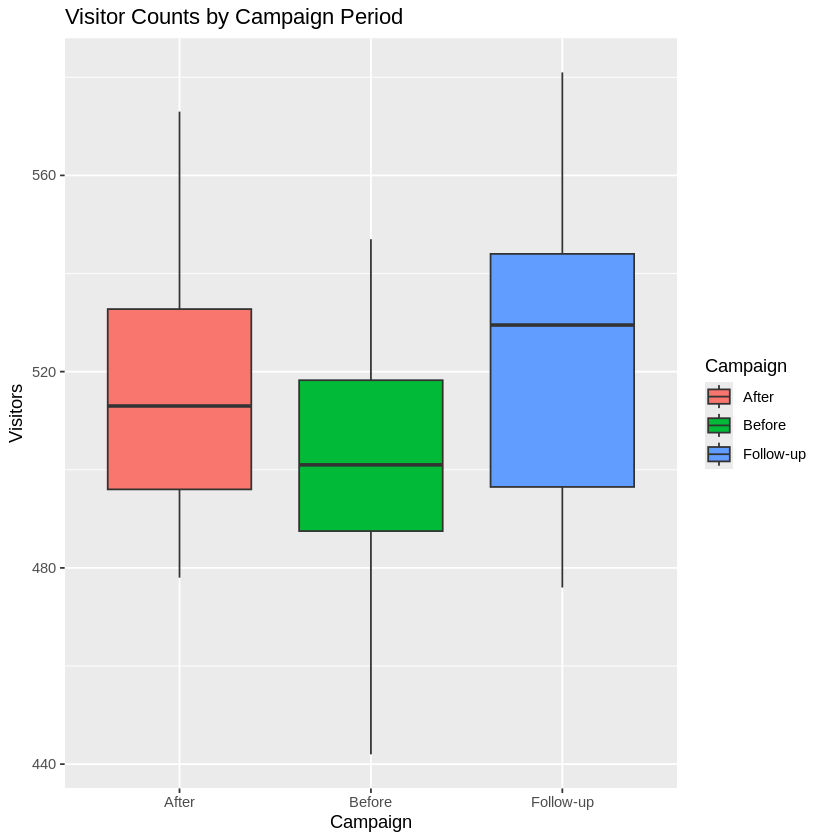

In [5]:
ggplot(df, aes(x = Campaign, y = Visitors, fill = Campaign)) +
  geom_boxplot() +
  labs(title = "Visitor Counts by Campaign Period")



*   ###### The medians are slightly different where the follow-up period appears to have the highest median.
*  ###### However, there is significant overlap in the spread (interquartile range) of all three boxes.


*  ###### The “Before” group has a more compact distribution, suggesting lower variability in that phase.
*   ###### There are no extreme outliers, and the ranges are relatively similar across all periods.







#### Option 2 : Tukey’s Honest Significant Difference (HSD) test

a post-hoc pairwise comparison used after ANOVA to:

* ###### Compare each pair of campaign periods
* ###### Control for multiple comparisons (adjusts p-values to reduce false positives)
* ###### Tell you exactly which pairs differ significantly

In [6]:
TukeyHSD(anova_model)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Visitors ~ Campaign, data = df)

$Campaign
                       diff        lwr      upr     p adj
Before-After     -11.857143 -38.169264 14.45498 0.5210897
Follow-up-After    8.642857 -17.669264 34.95498 0.7050794
Follow-up-Before  20.500000  -5.812121 46.81212 0.1527248


###### We tested whether the marketing campaign led to a statistically significant increase in website traffic.

###### The results of the t-test between 'Before' and 'After' showed no significant difference (p > 0.05).

###### The ANOVA comparing 'Before', 'After', and 'Follow-up' periods also showed no significant change.

###### Lastly, a separate t-test comparing 'After' vs 'Follow-up' indicated no sustained growth.

###### **Conclusion:** There is insufficient statistical evidence to claim the campaign significantly impacted visitor traffic.

**a simple explanation for stakeholders:**

###### Based on our analysis of website traffic before, during, and after the marketing campaign, we did not find strong statistical evidence that the campaign significantly increased the number of daily visitors.

###### While there were small changes across the periods, these differences could be due to normal fluctuations rather than the campaign itself.

###### This means we cannot confidently attribute any observed increase in traffic to the marketing efforts alone.